#### 🧾Section 1: Import Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import joblib

#### 📥Section 2: Load Data

In [2]:
# Load the dataset
df = pd.read_csv('data/creditcard.csv')

# View the first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#### 🔍Section 3: Data Exploration (EDA)

In [3]:
# Check basic info and stats, null and unique values
df.info()
df.describe()
df.isnull().sum()
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Time      124592
V1        275663
V2        275663
V3        275663
V4        275663
V5        275663
V6        275663
V7        275663
V8        275663
V9        275663
V10       275663
V11       275663
V12       275663
V13       275663
V14       275663
V15       275663
V16       275663
V17       275663
V18       275663
V19       275663
V20       275663
V21       275663
V22       275663
V23       275663
V24       275663
V25       275663
V26       275663
V27       275663
V28       275663
Amount     32767
Class          2
dtype: int64

In [4]:
# Check Class distribution
df['Class'].value_counts(normalize=True)  # 0 = Non-Fraud, 1 = Fraud

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

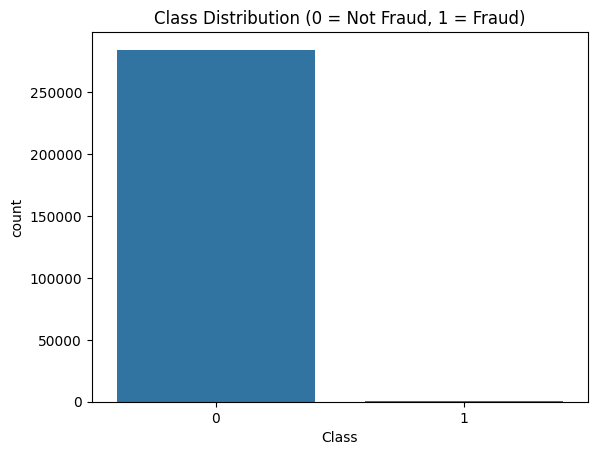

In [5]:
# Visazlize the class imbalance
sns.countplot(data=df, x='Class')
plt.title('Class Distribution (0 = Not Fraud, 1 = Fraud)')
plt.show()

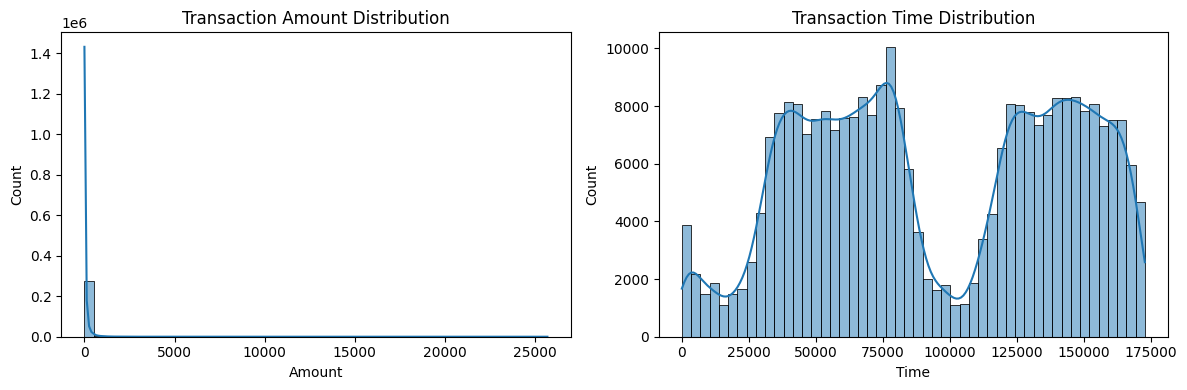

In [6]:
# Check distribution of Amount and Time
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Transaction Amount Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['Time'], bins=50, kde=True)
plt.title('Transaction Time Distribution')

plt.tight_layout()
plt.show()

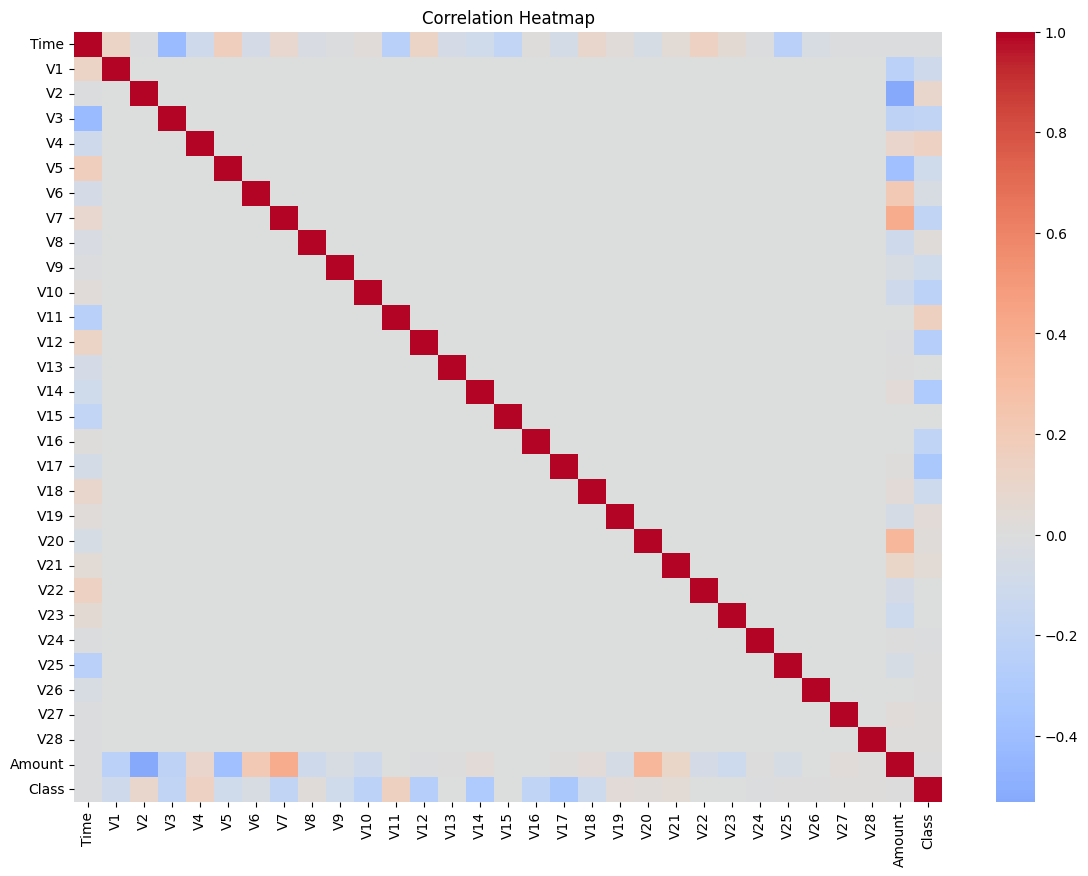

In [7]:
# Visualize Correlations
corr_matrix = df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

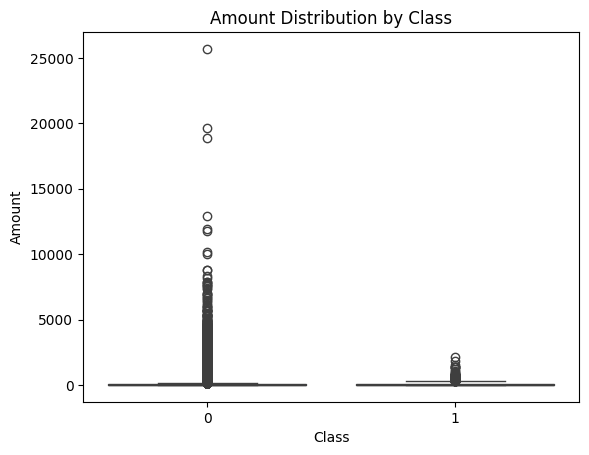

In [8]:
# Compare Amounts in Fraud vs Non-Fraud
sns.boxplot(data=df, x='Class', y='Amount')
plt.title('Amount Distribution by Class')
plt.show()

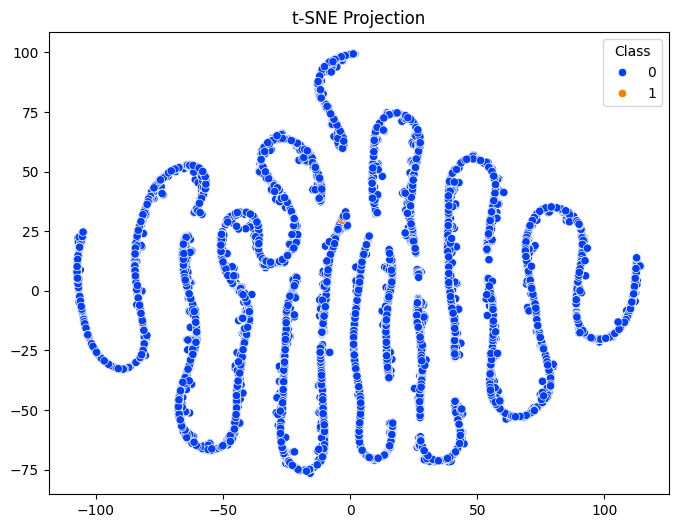

In [9]:
# t-SNE for high-dimensional visualization
X_sample = df.sample(10000, random_state=1)
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_sample.drop('Class', axis=1))

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=X_sample['Class'], palette='bright')
plt.title("t-SNE Projection")
plt.show()

#### 📊Section 4: Data Cleaning | Preprocessing | Train-Test Split

In [10]:
# Fit scalers
amount_scaler = StandardScaler()
time_scaler = StandardScaler()

# Transform using the fitted scalers
df['scaled_amount'] = amount_scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = time_scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original columns
df.drop(['Amount', 'Time'], axis=1, inplace=True)

In [11]:
# Reorder Columns
scaled_time = df['scaled_time']
scaled_amount = df['scaled_amount']
df.drop(['scaled_time', 'scaled_amount'], axis=1, inplace=True)

df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

In [12]:
# Train-Test Split
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#### 🧠Section 6: Model Building - Logistic Regression and Random Forest

In [13]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Results")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("ROC AUC Score:", roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1]))

Logistic Regression Results
[[56851    13]
 [   35    63]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.9572835078037969


In [14]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

Random Forest Results
[[56859     5]
 [   19    79]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.81      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.9476681922065394


#### 🏗️Section 7: Handling Class Imbalance using SMOTE

In [15]:
# Apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Original training set shape:", X_train.shape, y_train.value_counts())
print("Resampled training set shape:", X_train_res.shape, y_train_res.value_counts())

Original training set shape: (227845, 30) Class
0    227451
1       394
Name: count, dtype: int64
Resampled training set shape: (454902, 30) Class
0    227451
1    227451
Name: count, dtype: int64


In [16]:
# Train Random Forest on SMOTE Data
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_res, y_train_res)
y_pred_rf_smote = rf_smote.predict(X_test)

print("Random Forest (SMOTE) Results")
print(confusion_matrix(y_test, y_pred_rf_smote))
print(classification_report(y_test, y_pred_rf_smote))
print("ROC AUC Score:", roc_auc_score(y_test, rf_smote.predict_proba(X_test)[:, 1]))

Random Forest (SMOTE) Results
[[56851    13]
 [   18    80]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.82      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.9791124437253798


#### 🧠Section 8: XGBoost Implementation & Model Building

In [17]:
# Train the XGBoost Model
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [18]:
# Evalute the XGBoost Model
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_xgb))

Confusion Matrix:
 [[56404   460]
 [   11    87]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.16      0.89      0.27        98

    accuracy                           0.99     56962
   macro avg       0.58      0.94      0.63     56962
weighted avg       1.00      0.99      0.99     56962

ROC AUC Score: 0.9770518523250605


#### 🔍Section 9: XGBoost Model Evaluation Summary

| Metric         | Class 0 (Not Fraud) | Class 1 (Fraud) |
|----------------|---------------------|------------------|
| Precision      | 1.00                | **0.16**          |
| Recall         | **0.99**            | **0.89**          |
| F1-Score       | 1.00                | **0.27**          |

- Accuracy: 99%
- ROC AUC Score: 0.977

##### ✅ Strengths:
- Recall for fraud (1) is excellent at 89% — it's catching most of the frauds!
- ROC AUC is very strong — your model ranks fraud vs. non-fraud well in terms of probability.

##### ⚠️ Weaknesses:
- Precision for fraud (1) is low (16%), meaning many false positives (i.e., normal transactions flagged as fraud).
- This might cause unnecessary alerts in production.

#### 🧠 Final Thoughts:
- **XGBoost** + **SMOTE** did well in recall and AUC, making it a strong choice if the business goal is to catch as many frauds as possible, even if it means raising a few false alarms.
- You could tune XGBoost hyperparameters to reduce false positives and improve precision.

#### ⚙️Hyperparameter Tuning for XGBoost (RandomizedSearchCV)

In [19]:
# Hyperparameter tuning for XGBoost
params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.3],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "scale_pos_weight": [1, 10, 25, 50, 100]  # Try large values due to imbalance
}

xgb = XGBClassifier(eval_metric="logloss")

rs = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params,
    n_iter=30,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X_train, y_train)
print("Best parameters:", rs.best_params_)
best_model = rs.best_estimator_

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'subsample': 0.8, 'scale_pos_weight': 25, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [20]:
# Evaluate Best Model
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_best))

Confusion Matrix:
 [[56854    10]
 [   17    81]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score: 0.9797260631883592


#### 📤Export the XGBosst model and the scaler

In [22]:
# Save the XGBoost model
joblib.dump(best_model, 'xgboost_model.pkl')

# Save the scalers
joblib.dump(amount_scaler, 'amount_scaler.pkl')
joblib.dump(time_scaler, 'time_scaler.pkl')

['time_scaler.pkl']